In [1]:
!pip install -r https://raw.githubusercontent.com/rasbt/reasoning-from-scratch/refs/heads/main/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 148.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 148.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.3 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [2]:
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)
 
device = get_device()
device = torch.device("cpu")
 
model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using NVIDIA CUDA GPU
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


In [3]:
from reasoning_from_scratch.ch03 import render_prompt
 
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


In [4]:
from reasoning_from_scratch.ch02_ex import generate_text_basic_stream_cache
 
 
def generate_text_stream_concat_flex(
    model, tokenizer, prompt, device, max_new_tokens,
    verbose=False, 
    generate_func=None,
    **generate_kwargs
):
 
    if generate_func is None:
        generate_func = generate_text_basic_stream_cache
        
    input_ids = torch.tensor(
        tokenizer.encode(prompt), device=device
        ).unsqueeze(0)
 
    generated_ids = []
    for token in generate_func(
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())
 
        if verbose:
            print(
                tokenizer.decode(next_token_id.tolist()),
                end="",
                flush=True
            )
    return tokenizer.decode(generated_ids)

In [5]:
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_basic_stream_cache
)

 \boxed{10}

In [7]:
prompt_cot = prompt + " \n\nExplain step by step."

render_prompt(prompt_cot)
print(prompt_cot)
 
response_cot = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer: 

Explain step by step.
 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
According to the problem, half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

In [8]:
ex_prompt = "The capital of Germany is"
 
response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=1, verbose=True
)

 Berlin

In [9]:
input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)
print(input_token_ids)

tensor([[ 785, 6722,  315, 9856,  374]])


In [11]:
with torch.inference_mode():
    print(model(input_token_ids))
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

tensor([[[ 3.4688,  5.7812, -6.1875,  ..., -2.5781, -2.5781, -2.5781],
         [ 8.8125, 11.3125,  5.2812,  ...,  0.7539,  0.7539,  0.7539],
         [ 8.3125,  8.8125,  5.8438,  ...,  0.9023,  0.9023,  0.9023],
         [13.4375, 11.9375, 10.8750,  ..., -0.3887, -0.3887, -0.3887],
         [ 8.8750, 10.6250,  8.6250,  ..., -2.1719, -2.1719, -2.1719]]],
       dtype=torch.bfloat16)
torch.Size([1, 151936])


In [12]:
max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID: 19846
Decoded token: ' Berlin'


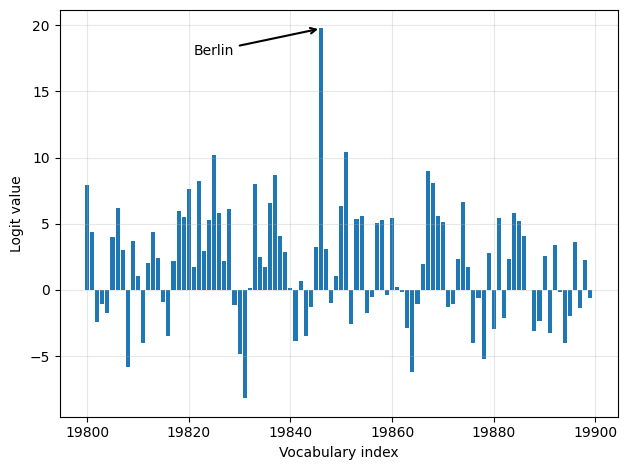

In [13]:
import matplotlib.pyplot as plt
 
def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900,
    arrow=True, ylabel="Logit value"
):
    x = torch.arange(start, end)
    logits_section = next_token_logits[0, start:end].float().cpu()
 
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)
 
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )
 
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
 
plot_scores_bar(next_token_logits)